In [7]:
# 1. Import packages
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
from sqlalchemy import create_engine, types
from sqlalchemy import text # to be able to pass string

In [9]:
# 1. Set up connection (update credentials and host!)
from dotenv import dotenv_values

config = dotenv_values() 

# define variables for the login
pg_user = config['POSTGRES_USER']  # align the key label with your .env file !
pg_host = config['POSTGRES_HOST']
pg_port = config['POSTGRES_PORT']
pg_db = config['POSTGRES_DB']
pg_schema = config['POSTGRES_SCHEMA']
pg_pass = config['POSTGRES_PASS']

url = f'postgresql://{pg_user}:{pg_pass}@{pg_host}:{pg_port}/{pg_db}'

engine = create_engine(url, echo=False)



In [10]:
# 2. Load data

my_schema = "team_3"

df = pd.read_sql(
    f"SELECT * FROM {my_schema}.mart_all_data;",
    engine,
    parse_dates=['transaction_date']
)

Defining the Prediction Window and Target
Goal: Set a cutoff date (e.g., July 1, 2019) and split your data into:
- Feature period: All data up to the cutoff (for calculating customer features)
- Target period: All data after the cutoff (for calculating future spend, which is the target)

For each customer, sum their revenue in the 6 months after the cutoff date.

This value is called their actual 6-month LTV and is what your predictive model will try to forecast.

In [11]:
# 3. Checking the best cutoff dates

cutoff_dates = ['2019-03-01', '2019-04-01', '2019-05-01']
results = []

for cutoff_str in cutoff_dates:
    cutoff_date = pd.Timestamp(cutoff_str)
    features_df = df[df['transaction_date'] < cutoff_date].copy()
    future_df = df[df['transaction_date'] >= cutoff_date].copy()
    
    # Feature engineering
    features_df['transaction_month_str'] = features_df['transaction_date'].dt.strftime('%Y-%m')
    
    cust_features = features_df.groupby('customer_id').agg(
        total_revenue=('revenue', 'sum'),
        avg_order_value=('revenue', 'mean'),
        frequency=('transaction_id', 'nunique'),
        recency_days=('transaction_date', lambda x: (cutoff_date - x.max()).days),
        tenure_days=('transaction_date', lambda x: (x.max() - x.min()).days + 1),
        n_months_active=('transaction_month_str', 'nunique'),
        avg_discount=('discount_pct', 'mean'),
        coupon_usage_rate=('coupon_status', lambda x: (x == 'Used').mean()),
        gender=('customer_gender', 'first'),
        location=('customer_location', 'first'),
    ).reset_index()
    
    # Target: 6M LTV (all revenue after cutoff)
    future_ltv = future_df.groupby('customer_id')['revenue'].sum().reset_index(name='future_6m_ltv')
    cust_features = cust_features.merge(future_ltv, on='customer_id', how='left')
    cust_features['future_6m_ltv'] = cust_features['future_6m_ltv'].fillna(0)
    
    # Encode categorical
    X = cust_features.drop(columns=['customer_id', 'future_6m_ltv'])
    X = pd.get_dummies(X, columns=['gender', 'location'], drop_first=True)
    y = cust_features['future_6m_ltv']
    
    # Split & train model
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    # Other metrics
    mean_ltv = y_test.mean()
    median_ltv = y_test.median()
    num_nonzero = (y_test > 0).sum()
    num_customers = len(y_test)
    
    print(f"Cutoff: {cutoff_str} | RMSE: {rmse:.2f} | Mean 6M LTV: {mean_ltv:.2f} | Median: {median_ltv:.2f} | Nonzero LTV: {num_nonzero}/{num_customers}")
    
    # Save results
    results.append({
        'cutoff_date': cutoff_str,
        'rmse': rmse,
        'mean_6m_ltv': mean_ltv,
        'median_6m_ltv': median_ltv,
        'num_nonzero_ltv': num_nonzero,
        'num_customers': num_customers
    })

# Convert results to DataFrame for easy comparison
results_df = pd.DataFrame(results)
print(results_df)


Cutoff: 2019-03-01 | RMSE: 6362.24 | Mean 6M LTV: 3058.42 | Median: 790.62 | Nonzero LTV: 43/63
Cutoff: 2019-04-01 | RMSE: 3845.34 | Mean 6M LTV: 2474.35 | Median: 151.25 | Nonzero LTV: 56/98
Cutoff: 2019-05-01 | RMSE: 5115.46 | Mean 6M LTV: 2597.11 | Median: 100.55 | Nonzero LTV: 73/131
  cutoff_date         rmse  mean_6m_ltv  median_6m_ltv  num_nonzero_ltv  \
0  2019-03-01  6362.242810  3058.419841        790.620               43   
1  2019-04-01  3845.336433  2474.354082        151.255               56   
2  2019-05-01  5115.464444  2597.113664        100.550               73   

   num_customers  
0             63  
1             98  
2            131  


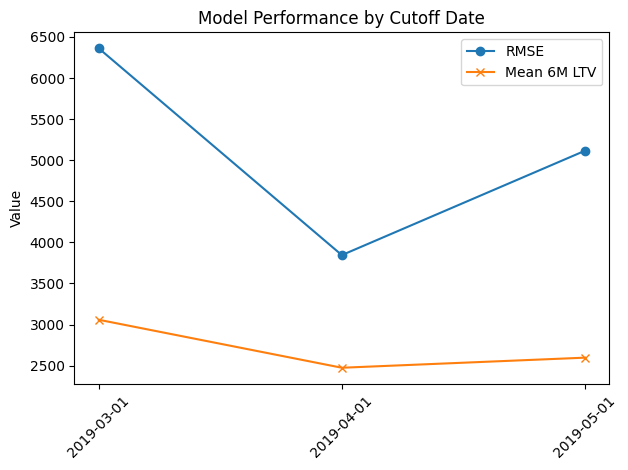

In [12]:
import matplotlib.pyplot as plt
plt.plot(results_df['cutoff_date'], results_df['rmse'], marker='o', label='RMSE')
plt.plot(results_df['cutoff_date'], results_df['mean_6m_ltv'], marker='x', label='Mean 6M LTV')
plt.xticks(rotation=45)
plt.ylabel('Value')
plt.title('Model Performance by Cutoff Date')
plt.legend()
plt.tight_layout()
plt.show()

In [13]:

# 1. Set cutoff date
cutoff_date = pd.Timestamp('2019-04-01')
features_df = df[df['transaction_date'] < cutoff_date].copy()
future_df = df[df['transaction_date'] >= cutoff_date].copy()

In [14]:
# 2. Feature engineering
features_df['transaction_month_str'] = features_df['transaction_date'].dt.strftime('%Y-%m')
cust_features = features_df.groupby('customer_id').agg(
    total_revenue=('revenue', 'sum'),
    avg_order_value=('revenue', 'mean'),
    frequency=('transaction_id', 'nunique'),
    recency_days=('transaction_date', lambda x: (cutoff_date - x.max()).days),
    tenure_days=('transaction_date', lambda x: (x.max() - x.min()).days + 1),
    n_months_active=('transaction_month_str', 'nunique'),
    avg_discount=('discount_pct', 'mean'),
    coupon_usage_rate=('coupon_status', lambda x: (x == 'Used').mean()),
    gender=('customer_gender', 'first'),
    location=('customer_location', 'first'),
).reset_index()

In [15]:
# 3. Target: 6M LTV (all revenue after cutoff)
future_ltv = future_df.groupby('customer_id')['revenue'].sum().reset_index(name='future_6m_ltv')
cust_features = cust_features.merge(future_ltv, on='customer_id', how='left')
cust_features['future_6m_ltv'] = cust_features['future_6m_ltv'].fillna(0)


In [17]:

# 4. Encode categorical
X = cust_features.drop(columns=['customer_id', 'future_6m_ltv'])
X = pd.get_dummies(X, columns=['gender', 'location'], drop_first=True)
y = cust_features['future_6m_ltv']

In [19]:
# 5. Train/test split and model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [20]:

# 6. Evaluate the model
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R^2: {r2:.2f}")
print(f"Test set mean LTV: {y_test.mean():.2f}")
print(f"Test set median LTV: {y_test.median():.2f}")

RMSE: 3845.34
MAE: 2689.66
R^2: 0.43
Test set mean LTV: 2474.35
Test set median LTV: 151.25


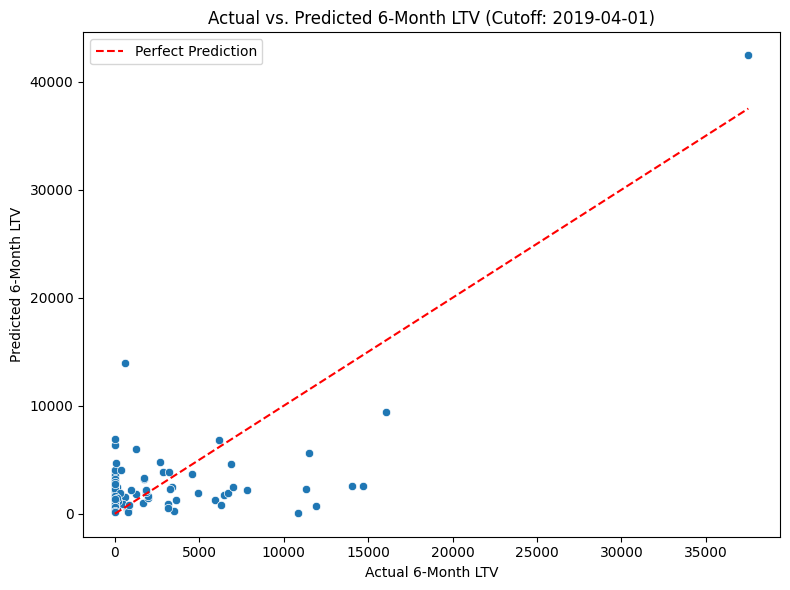

In [21]:
# 7. Visualize actual vs. predicted
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='Perfect Prediction')
plt.xlabel("Actual 6-Month LTV")
plt.ylabel("Predicted 6-Month LTV")
plt.title("Actual vs. Predicted 6-Month LTV (Cutoff: 2019-04-01)")
plt.legend()
plt.tight_layout()
plt.show()

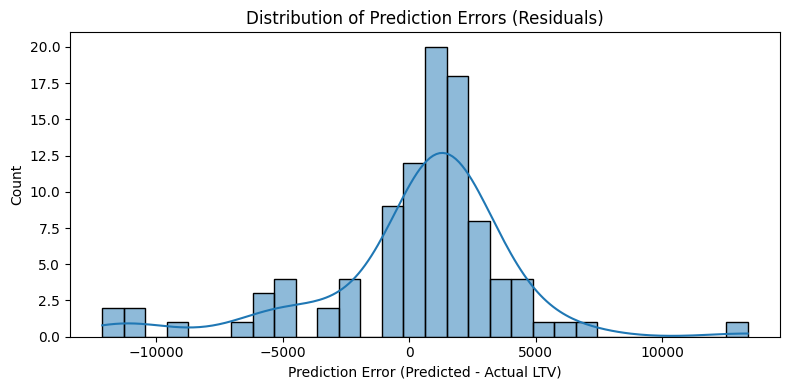

In [22]:
# 8. Visualize error distribution
errors = y_pred - y_test
plt.figure(figsize=(8,4))
sns.histplot(errors, bins=30, kde=True)
plt.title("Distribution of Prediction Errors (Residuals)")
plt.xlabel("Prediction Error (Predicted - Actual LTV)")
plt.tight_layout()
plt.show()

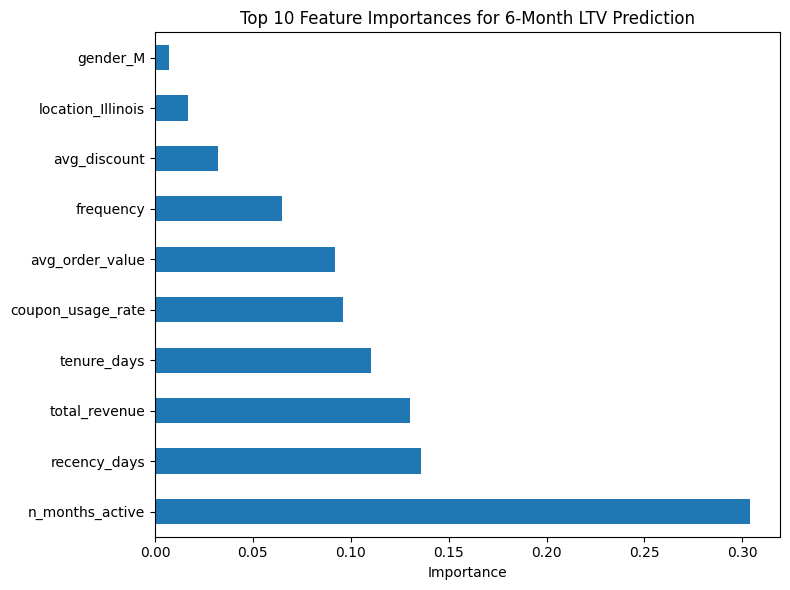

In [23]:
# 9. Feature importance
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
plt.figure(figsize=(8,6))
feat_importances.nlargest(10).plot(kind='barh')
plt.title('Top 10 Feature Importances for 6-Month LTV Prediction')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [25]:
# 6-month LTV (already computed)
mean_6m_ltv = cust_features['future_6m_ltv'].mean()
median_6m_ltv = cust_features['future_6m_ltv'].median()

# Full-year LTV (actual total 2019 revenue per customer)
full_year_ltv = df.groupby('customer_id')['revenue'].sum().reset_index(name='full_year_ltv')
mean_full_ltv = full_year_ltv['full_year_ltv'].mean()
median_full_ltv = full_year_ltv['full_year_ltv'].median()

print(f"Average actual 6M LTV: {mean_6m_ltv:.2f}")
print(f"Median actual 6M LTV: {median_6m_ltv:.2f}")
print(f"Average actual full-year LTV: {mean_full_ltv:.2f}")
print(f"Median actual full-year LTV: {median_full_ltv:.2f}")
print(f"RMSE (for 6M LTV prediction): {rmse:.2f}")

Average actual 6M LTV: 2679.68
Median actual 6M LTV: 305.50
Average actual full-year LTV: 3560.92
Median actual full-year LTV: 1952.68
RMSE (for 6M LTV prediction): 3845.34


1. Typical Customer Value
Most customers in your test set spend much less than the mean (median $305.50 vs. mean $2,679.68) in the 6 months after April 1.

The mean is much higher than the median, indicating that there are a few high-value outliers who drive up the average.

2. RMSE Compared to Typical LTV
RMSE ($3,845.34) is higher than both the average and median 6M LTV.

This means:
On average, the model’s prediction for a customer’s 6-month value is off by about $3,800.

Compared to the mean:
The error is 143% of the average 6M LTV ($3,845.34 / $2,679.68 ≈ 1.43).

Compared to the median:
The error is more than 10x the typical (median) customer’s spend.

3. Model Implications
Model is not accurate for most customers (especially those with low LTV).

Model's problem more likely are:

Many customers who spend nothing or very little after the cutoff (lots of zeros and small values).

A few customers who spend a lot, which the model cannot predict accurately (high variance).

Prediction is better for segmenting broad “high value” vs. “low value” customers than for predicting exact LTV for each individual.

4. Full-Year Context
Full-year median LTV ($1,952.68) is much higher than 6-month median ($305.50), again suggesting most purchases happen in the first half of the year, or many customers never return.



Capping outliers

In [33]:
# Cap future_6m_ltv at a chosen percentile, e.g., 99th
cap = cust_features['future_6m_ltv'].quantile(0.99)
cust_features['future_6m_ltv_capped'] = np.where(
    cust_features['future_6m_ltv'] > cap,
    cap,
    cust_features['future_6m_ltv']
)
# Use 'future_6m_ltv_capped' as your target variable
y = cust_features['future_6m_ltv_capped']

Retraining the model

In [32]:
# 2. Prepare features and new capped target
X = cust_features.drop(columns=['customer_id', 'future_6m_ltv', 'future_6m_ltv_capped'])
X = pd.get_dummies(X, columns=['gender', 'location'], drop_first=True)
y = cust_features['future_6m_ltv_capped']

# 3. Train-test split and model training
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 4. Evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"After capping outliers at 99th percentile:")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R^2: {r2:.2f}")
print(f"Test set mean LTV (capped): {y_test.mean():.2f}")
print(f"Test set median LTV (capped): {y_test.median():.2f}")

After capping outliers at 99th percentile:
RMSE: 3645.21
MAE: 2539.96
R^2: 0.14
Test set mean LTV (capped): 2266.13
Test set median LTV (capped): 151.25
